In [210]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import matplotlib.cm as cm
import colormaps as cmaps
import matplotlib.colors as colors
from labellines import labelLines
from matplotlib.cm import brg, ScalarMappable
from matplotlib.colors import (
    LogNorm,
    TwoSlopeNorm,
    LinearSegmentedColormap,
    Normalize,
    ListedColormap,
)
from matplotlib.lines import Line2D

import jax
import jax.numpy as jnp
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import yaml
from pathlib import Path

import EI.ei_unified as eu
import EI.ei_jax_2 as ej
import EI.ei_phonon as pb
from EI.ei_utils import gap_info
from fixed_baths import k_path, take_path, color_line, solve_state, plot_dispersion

from utils.logger import logger, tqdm_bar
from utils.plotting_utils import Plotter, plot_cmap, format_ax, add_legend, plot_cmap, plot_phase_diag, color_map


import importlib
pb = importlib.reload(pb)
ej = importlib.reload(ej)
jax.clear_caches()

In [211]:
from utils.cosmetics import apply_plt_style, SET1_LIST
apply_plt_style()

OUT = "/home/kzeleznikar/IJS-F1/Koda/EI_baths/"
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats("png", dpi=300)

In [212]:
cfg_path = Path("/home/kzeleznikar/IJS-F1/Koda/EI_baths/config/config_test.yaml")
cfg_ph_path = Path("/home/kzeleznikar/IJS-F1/Koda/EI_baths/config/config_phonons.yaml")

with cfg_path.open("r") as f:
    cfg = yaml.safe_load(f)
with cfg_ph_path.open("r") as f:
    cfg_ph = yaml.safe_load(f)

md = cfg_ph["model"]
eq = cfg_ph["equilibrium"]
sc = cfg_ph["scan"]
op = cfg_ph["open_system"]
op_prod = cfg["open_system"]

nk = md["nk"]
bp = md["band"]["pars"]

bd = eu.tb_2d(nk["scan"], **bp)
bd_ref = eu.tb_2d(nk["reference"], **bp)

p = eu.MFPars(**md["mean_field"])

In [213]:
s0 = eu.solve_eq(bd_ref, p, **eq["initial"], **eq["solve"])

d0 = abs(s0.d)
m0 = s0.m
mu0 = s0.mu

# za normalizacijo
tc = eu.critical_temperature(bd_ref, p, **eq["critical"])

logger.info(f"Delta_0 = {d0}")
logger.info(f"m_0     = {m0}")
logger.info(f"mu0     = {mu0}")
logger.info(f"T_c     = {tc}")

kriticna temp bisekcija:   0%|          | 0/100 [00:00<?, ?it/s]

[19:33:11] [INFO    ] Delta_0 = 1.003392658986832
[19:33:11] [INFO    ] m_0     = -0.9527761044421861
[19:33:11] [INFO    ] mu0     = 5.132560280957118
[19:33:11] [INFO    ] T_c     = 0.5496037150278688


In [214]:
tg = sc["temperature"]

tn = np.linspace( tg["min_ratio"], tg["max_ratio"], tg["nt"])

t1a = tn * tc
t2a = tn * tc
nt = tg["nt"]

In [215]:
st = ej.mf_state(bd_ref, p, s0.d, s0.m)
t1n, t2n = 6.5, 0.2
t1, t2 = t1n * tc, t2n * tc

In [216]:
st.eah

Array([8.71582681, 8.70005621, 8.65299313, ..., 8.55960918, 8.63722253,
       8.68428561], dtype=float64)

In [217]:
bc = op["bath"]
fn = getattr(pb, bc["rate"])
pa = dict(bc["pars"])

tb = 0.75 * tc

bs = (
    fn(
        tb, bd.k, name="constant",
        **{
            **pa,
            "disp": "constant",
            "w0": 1.1,
            "ew": 0.3,
        },
    ),
    fn(
        tb, bd.k, name="acoustic",
        **{
            **pa,
            "disp": "acoustic",
        },
    ),
    fn(
        tb, bd.k, name="gapped",
        **{
            **pa,
            "disp": "gapped",
            "length": 10.0,
        },
    ),
)

bl = ("constant", "acoustic", "gapped")

In [218]:
st = ej.mf_state(
    bd, p,
    d=float(s0.d),
    m=float(s0.m),
)

kg = np.asarray(bd.k, dtype=float)
ip = int(np.argmin(np.linalg.norm(kg, axis=1)))

per = 2.0 * np.pi / bs[0].a0
qk = (kg - kg[ip] + 0.5 * per) % per - 0.5 * per

gm = []

for b in tqdm(bs, desc="Coupling matrices"):
    z = [
        np.asarray(
            jax.device_get(
                pb.g_mat(st, b, ik, ip, qk[ik])
            )
        )
        for ik in range(bd.size)
    ]
    gm.append(np.stack(z))

gm = np.stack(gm)

Coupling matrices:   0%|          | 0/3 [00:00<?, ?it/s]

In [219]:
gm.shape

(3, 900, 2, 2)

In [220]:
mu = 0

kx = kg[:, 0].reshape(bd.shape)
ky = kg[:, 1].reshape(bd.shape)
z = np.abs(gm[:, :, :, mu])**2

zp = z[z > 0.0]
vmax = float(np.max(zp))
vmin = max(float(np.min(zp)), 1.0e-8 * vmax)
norm = LogNorm(vmin=vmin, vmax=vmax)

h = 1.55
fig, ax = plt.subplots(
    3, 2,
    sharex=True,
    sharey=True,
    figsize=(2 * 3.47412, h * 3.47412),
)

for ib in range(3):
    for nu in range(2):
        zz = z[ib, :, nu].reshape(bd.shape)
        zz = np.ma.masked_less_equal(zz, 0.0)

        im = ax[ib, nu].pcolormesh(
            kx, ky, zz,
            shading="nearest",
            cmap=cmaps.lipari,
            norm=norm,
        )
        im.set_edgecolor("face")

        ax[ib, nu].set_xlim(kx.min(), kx.max())
        ax[ib, nu].set_ylim(ky.min(), ky.max())
        ax[ib, nu].text(
            0.04, 0.94,
            rf"{bl[ib]}, $\nu={['alpha', 'beta'][nu]}$",
            transform=ax[ib, nu].transAxes,
            va="top",
        )

    ax[ib, 0].set_ylabel(r"$k_y$")

for a in ax[-1]:
    a.set_xlabel(r"$k_x$")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(
    rf"$|G_{{\nu,{mu}}}(\mathbf{{k}},\mathbf{{p}}_0)|^2$",
    rotation=90,
    labelpad=5,
)

plt.tight_layout()
plt.show()

ValueError: zero-size array to reduction operation maximum which has no identity

In [ ]:
mu = 0
ewp = 0.02

kg = np.asarray(bd.k, dtype=float)
ek = np.asarray(st.e, dtype=float)

ip = int(np.argmin(np.linalg.norm(kg, axis=1)))

per = 2.0 * np.pi / bs[0].a0
qk = (kg - kg[ip] + 0.5 * per) % per - 0.5 * per
qm = np.linalg.norm(qk, axis=1)

kx = kg[:, 0].reshape(bd.shape)
ky = kg[:, 1].reshape(bd.shape)

def delta_e(x, ew):
    return ew / (np.pi * (x * x + ew * ew))

z = np.zeros((len(bs), 2, bd.size))

for ib, b in enumerate(tqdm(bs, desc="Bose-energy factors")):
    om = np.asarray(
        jax.device_get(
            pb.omega_q(jnp.asarray(qm), b)
        )
    )

    nq = np.zeros_like(om)
    mq = om > 1.0e-12

    if b.t > 0.0:
        x = np.clip(om[mq] / b.t, 0.0, 700.0)
        nq[mq] = 1.0 / np.expm1(x)

    for nu in range(2):
        de = ek[nu] - ek[mu, ip]

        z[ib, nu] = (
            nq * delta_e(de - om, ewp)
            + (1.0 + nq) * delta_e(de + om, ewp)
        )

        z[ib, nu] = np.where(qm <= b.qd, z[ib, nu], 0.0)

    if b.disp == "acoustic":
        z[ib, :, ~mq] = np.nan

Bose-energy factors:   0%|          | 0/3 [00:00<?, ?it/s]

/tmp/ipykernel_44035/384693871.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


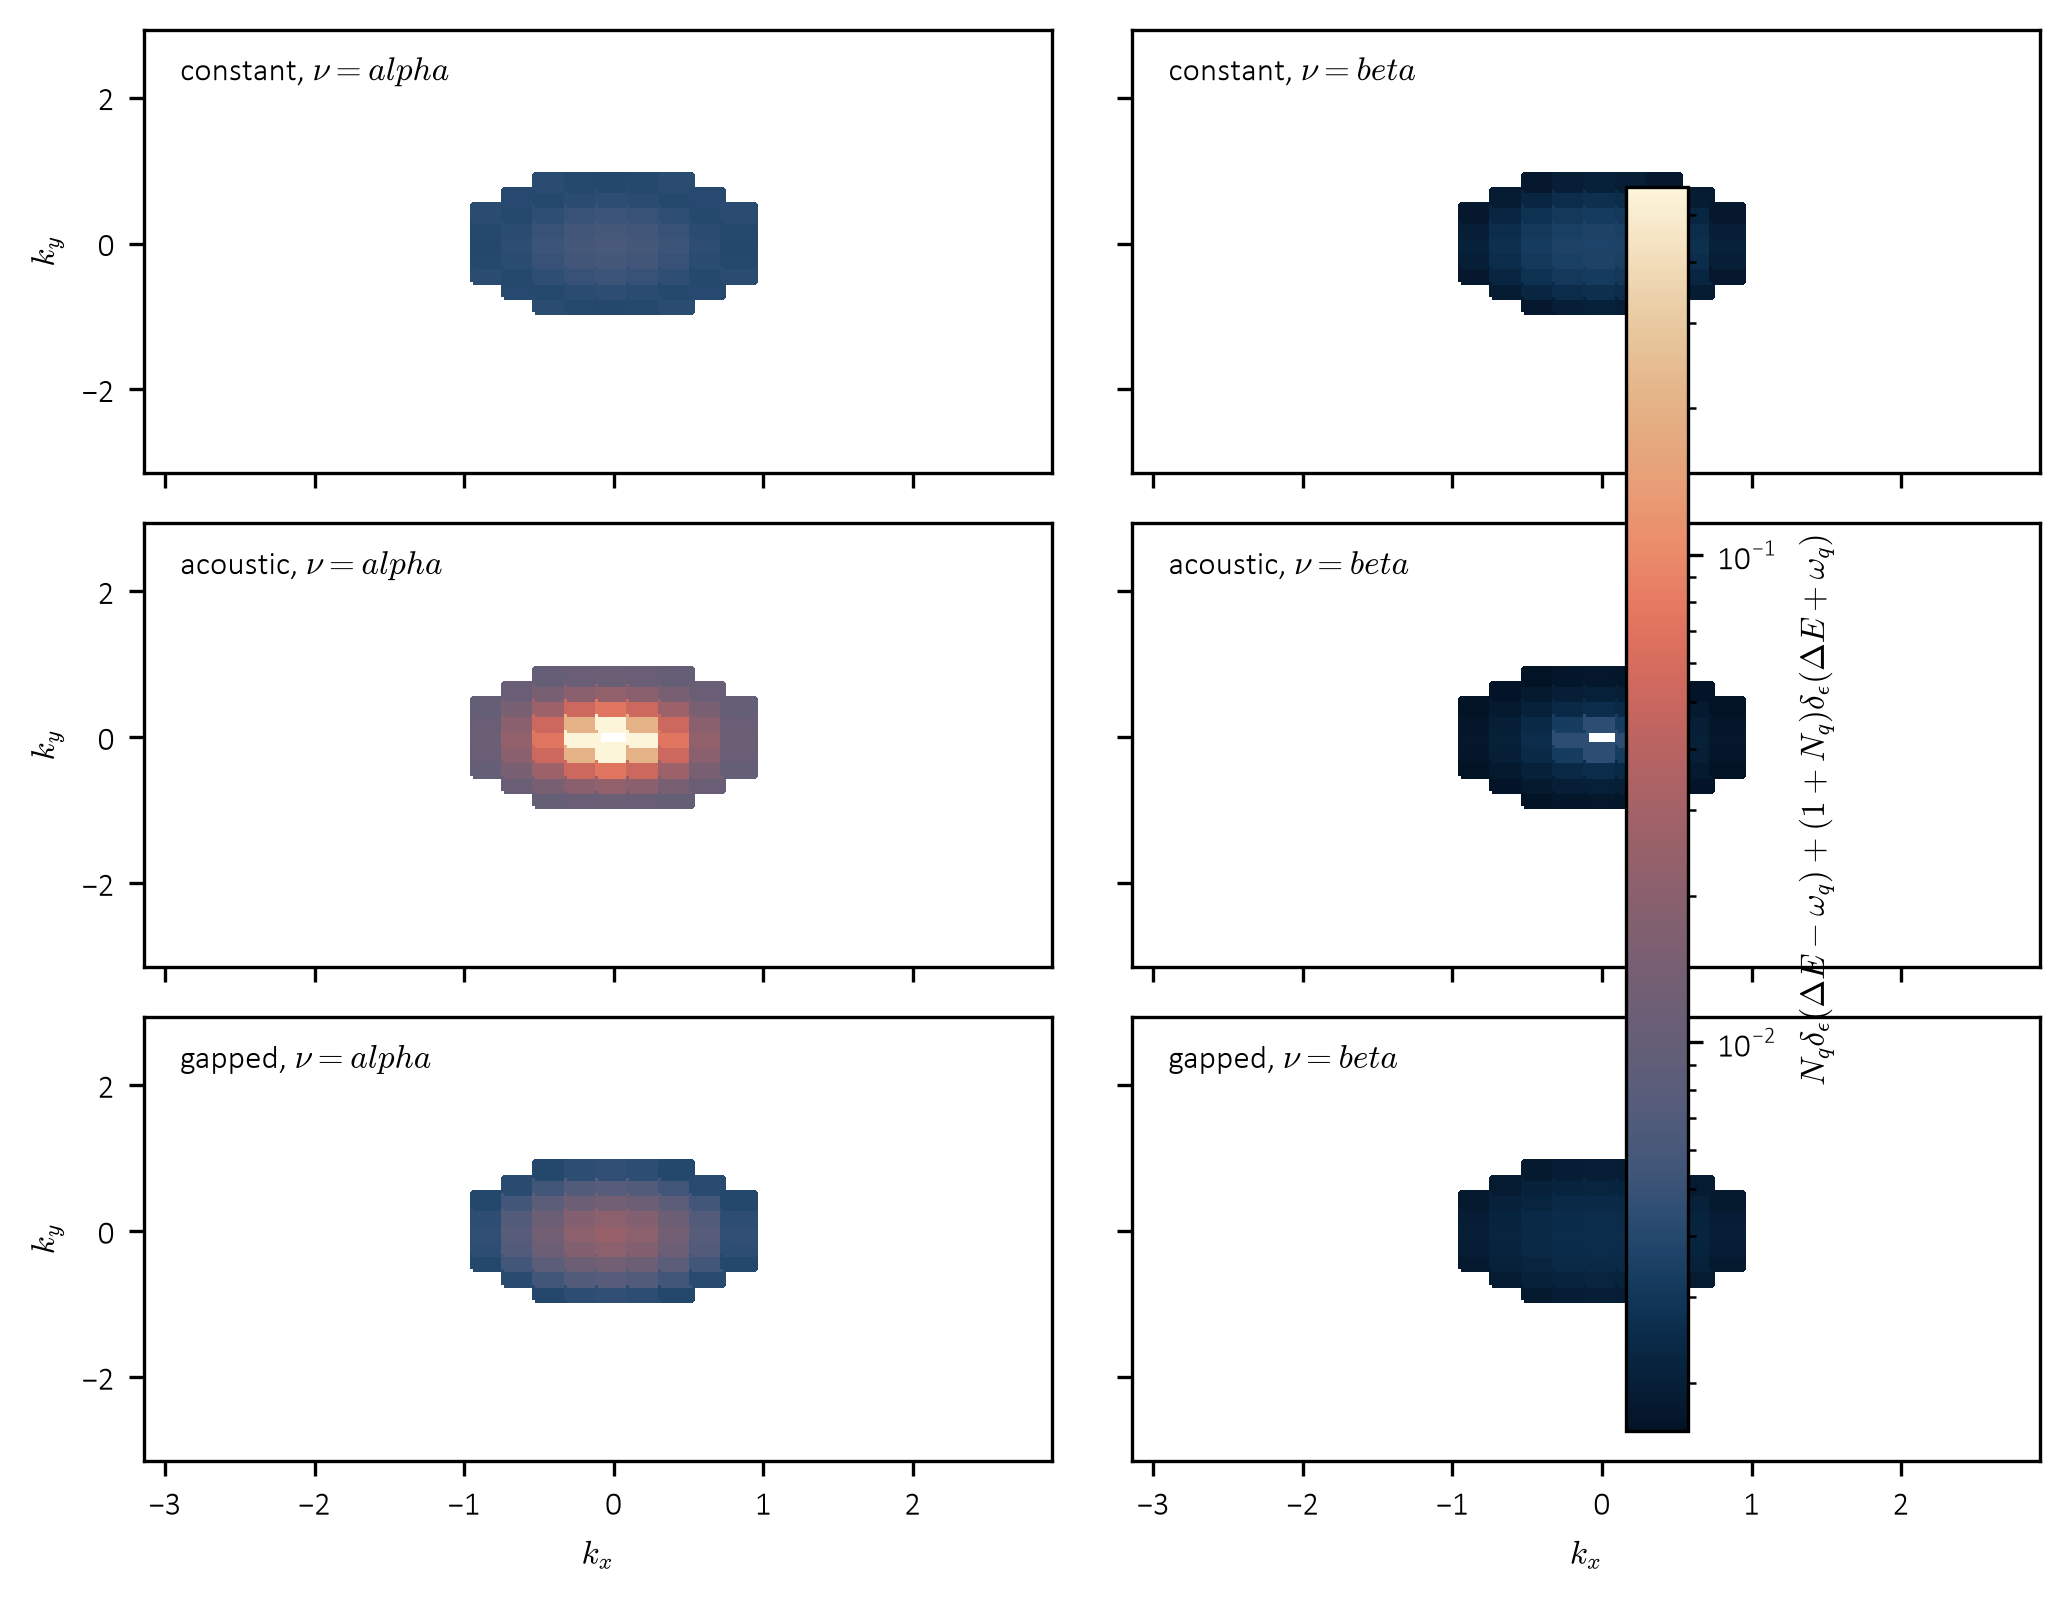

In [ ]:
zp = z[np.isfinite(z) & (z > 0.0)]
vmax = float(np.max(zp))
vmin = max(float(np.min(zp)), 1.0e-8 * vmax)
norm = LogNorm(vmin=vmin, vmax=vmax)

h = 1.55
fig, ax = plt.subplots(
    3, 2,
    sharex=True,
    sharey=True,
    figsize=(2 * 3.47412, h * 3.47412),
)

for ib in range(3):
    for nu in range(2):
        zz = np.ma.masked_invalid(
            z[ib, nu].reshape(bd.shape)
        )
        zz = np.ma.masked_less_equal(zz, 0.0)

        im = ax[ib, nu].pcolormesh(
            kx, ky, zz,
            shading="nearest",
            cmap=cmaps.lipari,
            norm=norm,
        )
        im.set_edgecolor("face")

        ax[ib, nu].set_xlim(kx.min(), kx.max())
        ax[ib, nu].set_ylim(ky.min(), ky.max())

        ax[ib, nu].text(
            0.04, 0.94,
            rf"{bl[ib]}, $\nu={['alpha', 'beta'][nu]}$",
            transform=ax[ib, nu].transAxes,
            va="top",
        )

    ax[ib, 0].set_ylabel(r"$k_y$")

for a in ax[-1]:
    a.set_xlabel(r"$k_x$")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(
    r"$N_q\delta_\epsilon(\Delta E-\omega_q)"
    r"+(1+N_q)\delta_\epsilon(\Delta E+\omega_q)$",
    rotation=90,
    labelpad=5,
)

plt.tight_layout()
plt.show()

In [ ]:
disp = "constant"
mu = 0

b = next(q for q in bs if q.disp == disp)

st = ej.mf_state(
    bd, p,
    d=float(s0.d),
    m=float(s0.m),
)

ij, x, xt = k_path(bd)

kg = np.asarray(bd.k, dtype=float)
ek = np.asarray(st.e, dtype=float)

ip = np.ravel_multi_index(
    tuple(ij[0]),
    bd.shape,
)

per = 2.0 * np.pi / b.a0
qk = (kg - kg[ip] + 0.5 * per) % per - 0.5 * per
qm = np.linalg.norm(qk, axis=1)

om = np.asarray(
    jax.device_get(
        pb.omega_q(jnp.asarray(qm), b)
    )
)

de = ek - ek[mu, ip]
# de=ek-md["mean_field"]["v"]/2
gm = []

for ik in tqdm(range(bd.size), desc="G matrix"):
    g = pb.g_mat(st, b, ik, ip, qk[ik])
    gm.append(np.asarray(jax.device_get(g)))

gm = np.stack(gm)
g2 = np.abs(gm[:, :, mu].T)**2

def delta_e(y, ew):
    return ew / (np.pi * (y * y + ew * ew))

nq = np.zeros_like(om)
mq = om > 1.0e-12

if b.t > 0.0:
    y = np.clip(om[mq] / b.t, 0.0, 700.0)
    nq[mq] = 1.0 / np.expm1(y)

bf = (
    nq[None, :] * delta_e(de - om[None, :], ewp)
    + (1.0 + nq[None, :])
    * delta_e(de + om[None, :], ewp)
)

bf[:, qm > b.qd] = 0.0

if b.disp == "acoustic":
    bf[:, ~mq] = np.nan


gr = np.asarray(
    jax.device_get(
        pb.source_rates(st, (b,), mu, ip)
    )
)
ep = take_path(de, ij, bd.shape)
wp = take_path(om, ij, bd.shape)
gp = take_path(g2, ij, bd.shape)
fp = take_path(bf, ij, bd.shape)
rp = take_path(gr, ij, bd.shape)

G matrix:   0%|          | 0/900 [00:00<?, ?it/s]

Phonon kernel table:   0%|          | 0/64 [00:00<?, ?it/s]

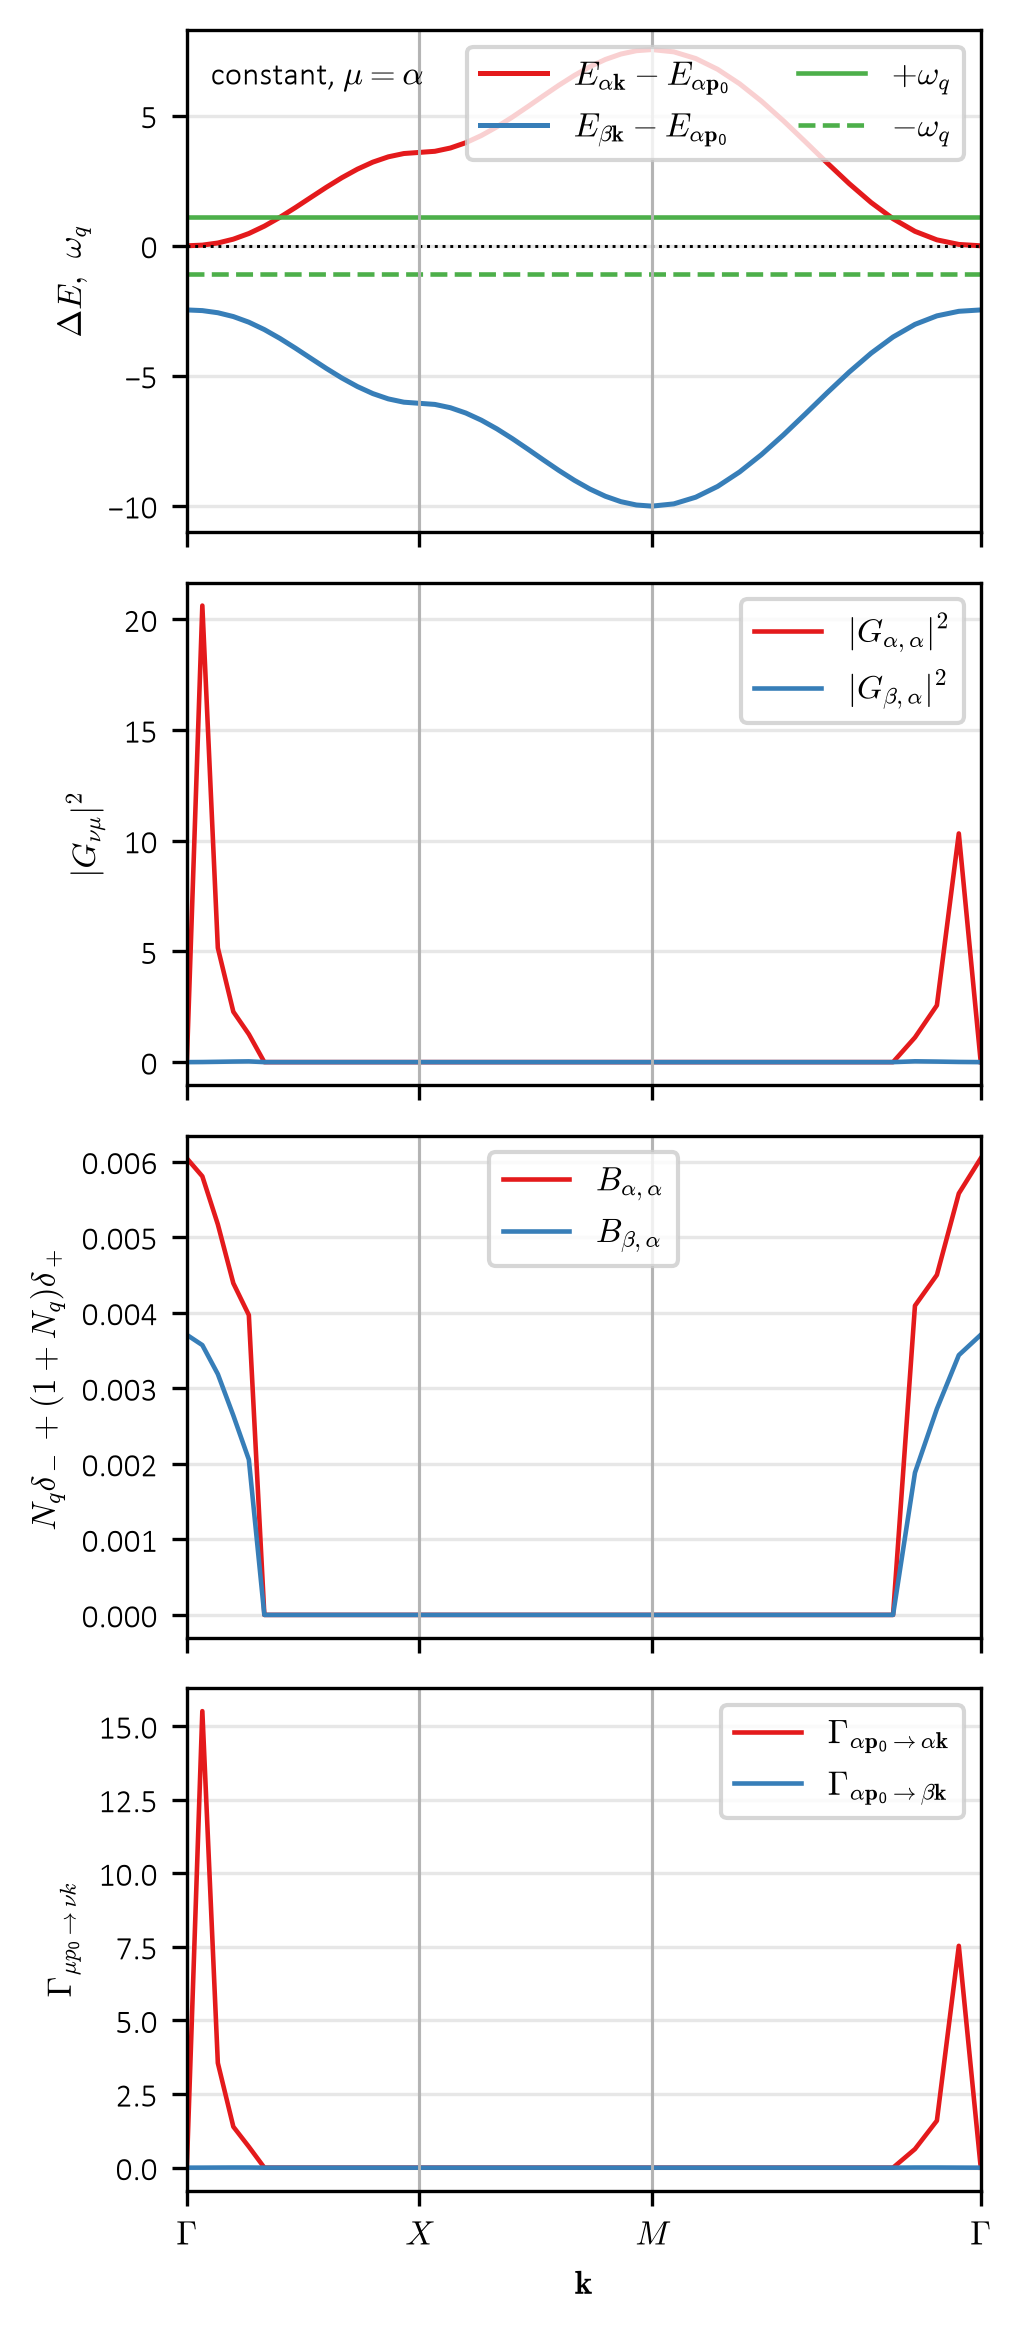

In [ ]:
h = 2.25
fig, ax = plt.subplots(
    4, 1,
    sharex=True,
    figsize=(3.47412, h * 3.47412),
)

cl = (SET1_LIST[0], SET1_LIST[1])
lb = (r"\alpha", r"\beta")

for nu in range(2):
    ax[0].plot(
        # x, take_path(ek, ij, bd.shape)[nu],
        x, ep[nu],
        color=cl[nu],
        linewidth=1.2,
        label = rf"$E_{{{lb[nu]}\mathbf{{k}}}}-E_{{{lb[mu]}\mathbf{{p}}_0}}$",
    )

ax[0].plot(
    x, wp,
    color=SET1_LIST[2],
    linewidth=1.1,
    label=r"$+\omega_{q}$",
)
ax[0].plot(
    x, -wp,
    color=SET1_LIST[2],
    linestyle="--",
    linewidth=1.1,
    label=r"$-\omega_{q}$",
)
ax[0].axhline(0.0, color="black", linestyle=":", linewidth=0.7)
ax[0].set_ylabel(r"$\Delta E,\ \omega_q$")
ax[0].legend(ncol=2)
ax[0].set_ylim(1.1*min(ep[nu]), 1.1*max(ep[mu]))


for nu in range(2):
    # y = np.where(gp[nu] > 0.0, gp[nu], np.nan)
    y=gp[nu]
    ax[1].plot(
        x, y,
        color=cl[nu],
        linewidth=1.1,
        label = rf"$|G_{{{lb[nu]},{lb[mu]}}}|^2$",
    )

ax[1].set_ylabel(r"$|G_{\nu\mu}|^2$")
ax[1].legend()

for nu in range(2):
    # y = np.where(fp[nu] > 0.0, fp[nu], np.nan)
    y=fp[nu]
    ax[2].plot(
        x, y,
        color=cl[nu],
        linewidth=1.1,
        label = rf"$B_{{{lb[nu]},{lb[mu]}}}$",
    )

ax[2].set_ylabel(
    r"$N_q\delta_-+(1+N_q)\delta_+$"
)
ax[2].legend()

for nu in range(2):
    # y = np.where(rp[nu] > 0.0, rp[nu], np.nan)
    y=rp[nu]
    ax[3].plot(
        x, y,
        color=cl[nu],
        linewidth=1.1,
        label = rf"$\Gamma_{{{lb[mu]}\mathbf{{p}}_0\rightarrow {lb[nu]}\mathbf{{k}}}}$",
    )

ax[3].set_ylabel(r"$\Gamma_{\mu p_0\rightarrow\nu k}$")
ax[3].set_xlabel(r"$\mathbf{k}$")
ax[3].legend()

for a in ax:
    a.set_xlim(x[0], x[-1])
    a.grid(alpha=0.3)

    for xv in xt[1:-1]:
        a.axvline(
            xv,
            color="0.7",
            linewidth=0.7,
        )

ax[-1].set_xticks(xt)
ax[-1].set_xticklabels(
    [r"$\Gamma$", r"$X$", r"$M$", r"$\Gamma$"]
)

ax[0].text(
    0.03, 0.94,
    rf"{disp}, $\mu={lb[mu]}$",
    transform=ax[0].transAxes,
    va="top",
)

plt.tight_layout()
plt.show()

In [ ]:
r1, r2 = 0.35, 1.5
t1, t2 = r1 * tc, r2 * tc
eta_a = np.array([0.025])

se = eu.solve_eq(
    bd, p, t=t1, d=d0, m=s0.m,
    **{**eq["solve"], "prog": False},
)

w = np.asarray(bd.w, dtype=float)

# ni = np.full_like(se.n, float(p.n) / (2.0 * np.sum(w)))
# di, mi = 0.8, -0.6
ni = se.n.copy()
di = float(se.d)
mi = float(se.m)

st0 = ej.mf_state(bd, p, d=di, m=mi)
pk = pb.pack(bs)

ee = np.asarray(st0.e).reshape(-1)
rr = np.asarray(ej.dense_rates(st0, bs))

print("energy interval:", ee.min(), ee.max())
print("max |Ei-Ej|:", np.ptp(ee))
print("bath em:", float(pk.em))
print("finite rates:", np.isfinite(rr).all())
print("nonfinite entries:", np.count_nonzero(~np.isfinite(rr)))

energy interval: -8.773814457408562 8.773814457408562
max |Ei-Ej|: 17.547628914817125
bath em: 17.7
finite rates: True
nonfinite entries: 0


In [ ]:
r1, r2 = 0.21, 5.5
t1, t2 = r1 * tc, r2 * tc
eta_a = np.array([0.025])

se = eu.solve_eq(
    bd, p, t=t1, d=d0, m=s0.m,
    **{**eq["solve"], "prog": False},
)

w = np.asarray(bd.w, dtype=float)

# ni = np.full_like(se.n, float(p.n) / (2.0 * np.sum(w)))
# di, mi = 0.8, -0.6
ni = se.n.copy()
di = float(se.d)
mi = float(se.m)

ns = int(op["solve"]["chk"]) 
nstep = int(op["solve"]["nmax"]) * 45

mix = (0.2, 0.2, 0.2)
tol = 1.0e-12

out = []
fin = []

for eta in tqdm(eta_a, desc="Energy widths"):
    bp = {
        **bc["pars"],
        "eta": float(eta),
        "disp": "constant",
        "w0": 1.5,
        "ew": 0.3,
    }
    # bp = {
    #     **bc["pars"],
    #     "eta": float(eta),
    #     "disp": "gapped",
    #     "length": 10.0,
    # }
    bs = (
        fn(t1, bd.k, name="bath_1", **bp),
        fn(t2, bd.k, name="bath_2", **bp),
    )

    so = ej.solve_fixed(
        bd, p, ni.copy(), bs,
        d=di, m=mi,
        mix=mix,
        tol=tol,
        nmax=nstep,
        chk=300,
        prog=True,
    )

    hq = so.hist

    si = ej.mf_state(bd, p, d=di, m=mi)
    ti = ej.targets(bd, p, si, ni)
    g0 = float(ti.d) / di
    a0 = float(np.sum(w * ni[0]))

    z = {
        "it": np.r_[0, hq["it"]],
        "d": np.r_[di, hq["d"]],
        "m": np.r_[mi, hq["m"]],
        "na": np.r_[a0, hq["na"]],
        "gn": np.r_[g0, hq["gn"]],
        "err": np.r_[np.nan, hq["err"]],
        "cur": np.r_[np.nan, hq["cur"]],
    }

    out.append({q: np.asarray(v) for q, v in z.items()})
    fin.append({
        "n": so.n.copy(),
        "d": float(so.d),
        "m": float(so.m),
        "err": float(so.err),
        "ok": bool(so.ok),
    })

Energy widths:   0%|          | 0/1 [00:00<?, ?it/s]

Fixed EI JAX:   0%|          | 0/1500 [00:00<?, ?it/s]

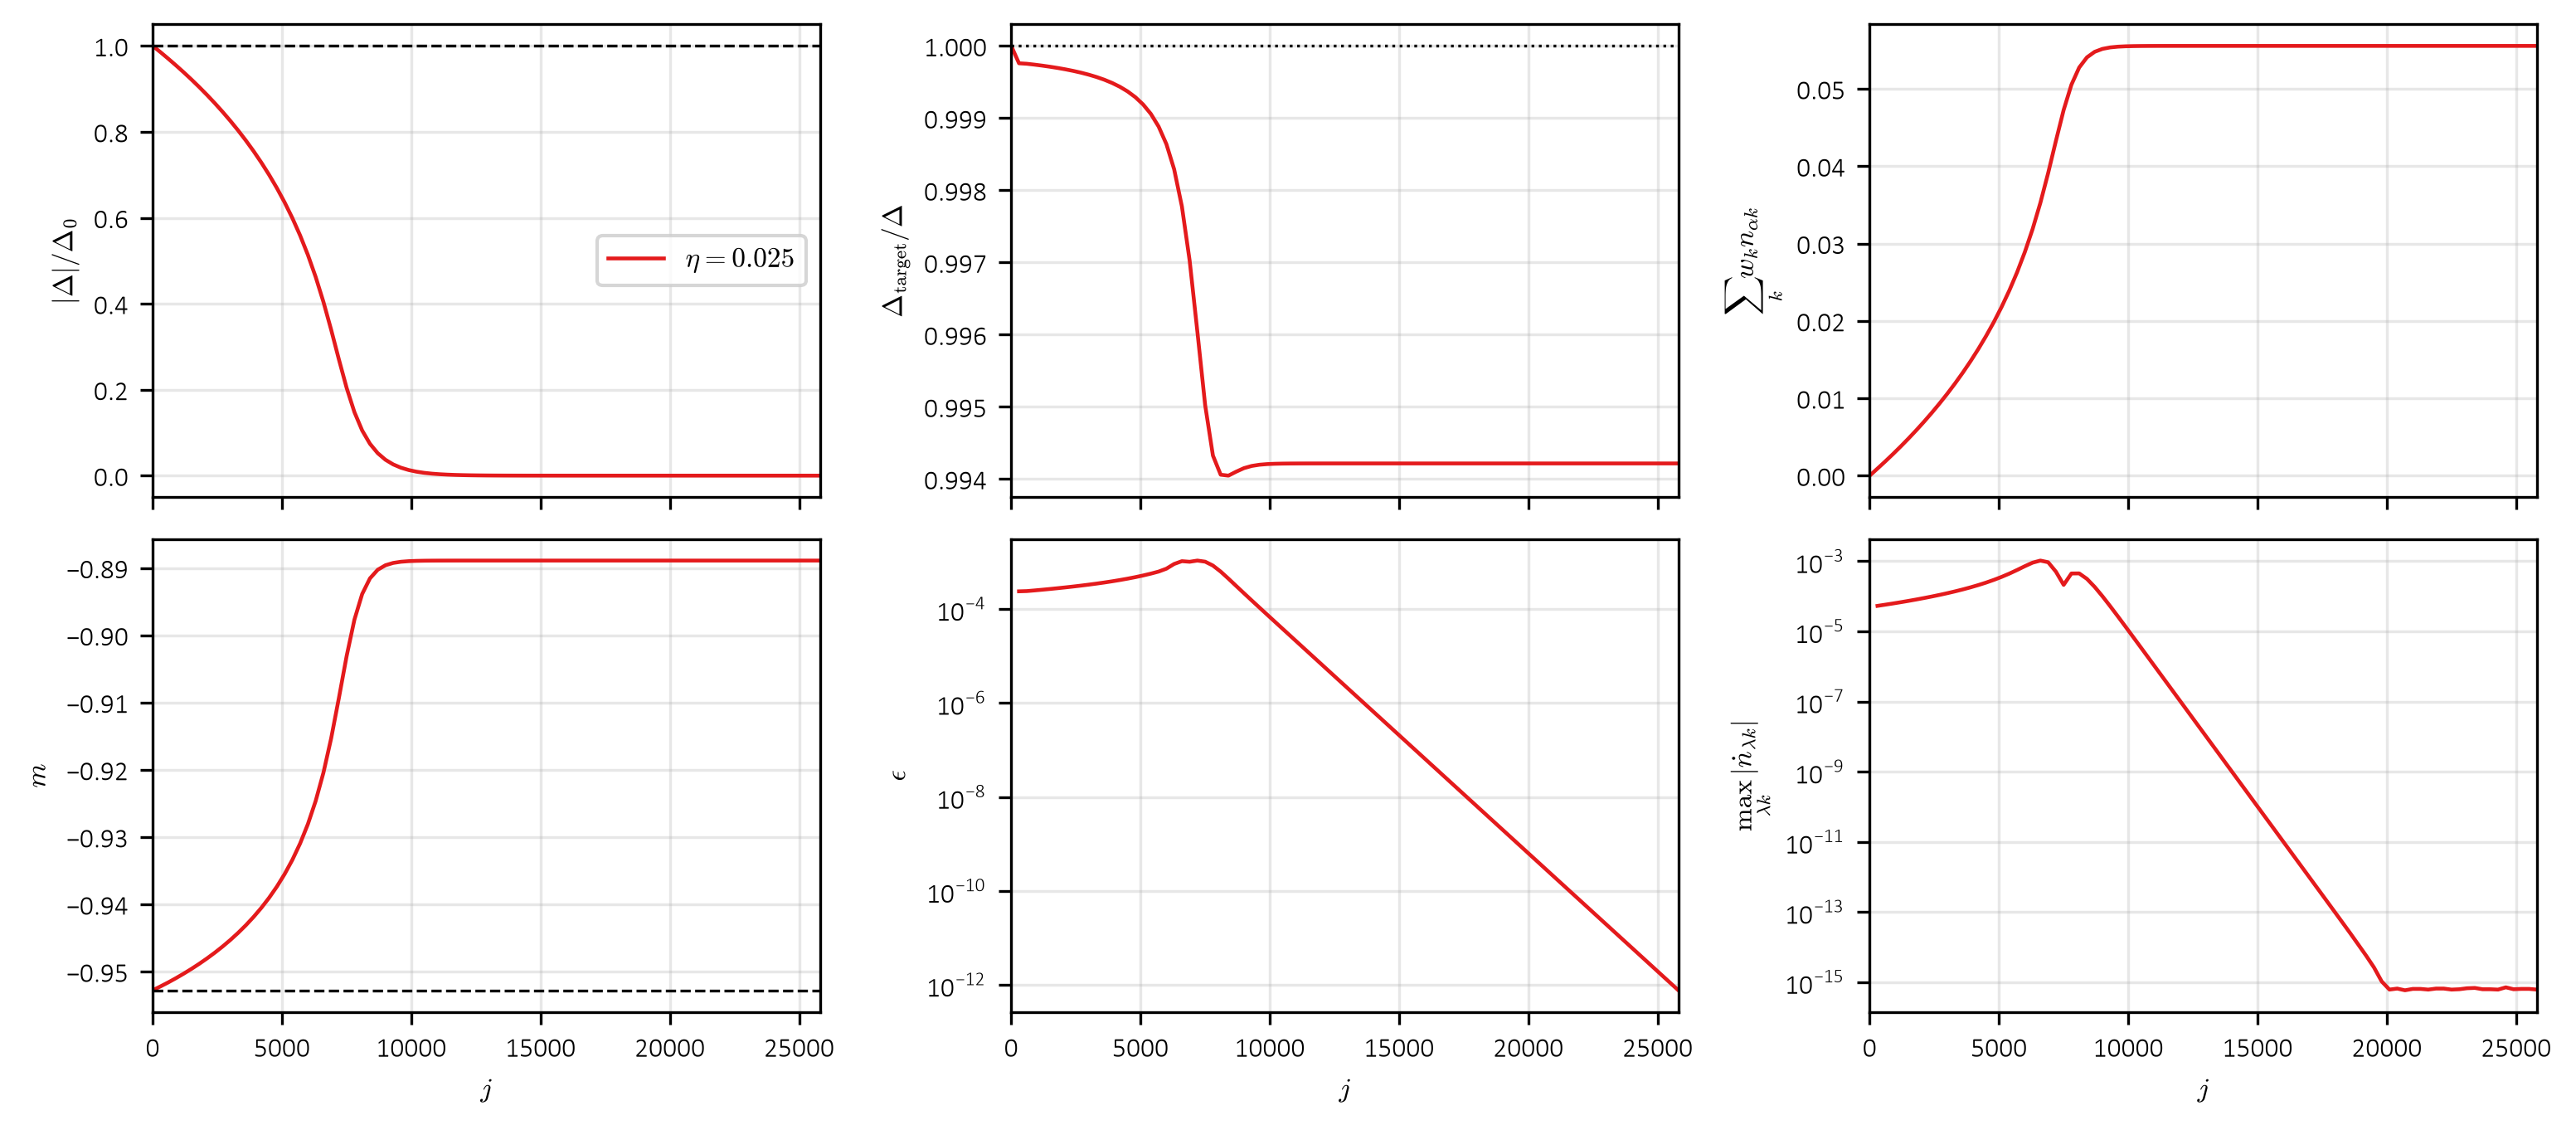

In [221]:
h = 1.45
fig, ax = plt.subplots(
    2, 3, sharex=True,
    figsize=(3 * 3.47412, h * 3.47412),
)

for i, eta in enumerate(eta_a):
    c = SET1_LIST[i]
    z = out[i]
    lb = rf"$\eta={eta:g}$"

    ax[0, 0].plot(
        z["it"], np.abs(z["d"]) / d0,
        color=c, linestyle="-", linewidth=1.1, label=lb,
    )
    ax[0, 1].plot(
        z["it"], z["gn"],
        color=c, linestyle="-", linewidth=1.1,
    )
    ax[0, 2].plot(
        z["it"], z["na"],
        color=c, linestyle="-", linewidth=1.1,
    )
    ax[1, 0].plot(
        z["it"], z["m"],
        color=c, linestyle="-", linewidth=1.1,
    )
    ax[1, 1].semilogy(
        z["it"][1:], z["err"][1:],
        color=c, linestyle="-", linewidth=1.1,
    )
    ax[1, 2].semilogy(
        z["it"][1:], z["cur"][1:],
        color=c, linestyle="-", linewidth=1.1,
    )

ax[0, 1].axhline(
    1.0, color="black",
    linestyle=":", linewidth=0.8,
)

ax[0, 0].axhline(
    se.d /d0, color="black",
    linestyle="--", linewidth=0.8,
)

ax[1, 0].axhline(
    se.m, color="black",
    linestyle="--", linewidth=0.8,
)
ax[0, 0].set_ylabel(r"$|\Delta|/\Delta_0$")
ax[0, 1].set_ylabel(r"$\Delta_{\mathrm{target}}/\Delta$")
ax[0, 2].set_ylabel(r"$\sum_k w_k n_{\alpha k}$")
ax[1, 0].set_ylabel(r"$m$")
ax[1, 1].set_ylabel(r"$\epsilon$")
ax[1, 2].set_ylabel(r"$\max_{\lambda k}|\dot n_{\lambda k}|$")

for a in ax.ravel():
    a.set_xlim(z["it"][0], z["it"][-1])
    a.grid(alpha=0.3)

for a in ax[1]:
    a.set_xlabel(r"$j$")

hd, lb = ax[0, 0].get_legend_handles_labels()
ax[0,0].legend()

plt.tight_layout(rect=(0, 0, 1, 0.91))
plt.show()

In [167]:
tn = np.asarray(tn, dtype=float)
t1a = tn * tc
t2a = tn * tc
nt = tn.size

bc = op["bath"]
bp = {**bc["pars"], "eta": float(eta), "disp": "constant", "w0": 1.5, "ew": 0.3,}
# bp = {**bc["pars"], "eta": float(eta), "disp": "acoustic"}

fp = {
    "mix": (0.2, 0.2, 0.2),
    "tol": 1.0e-5,
    "nmax": 100000,
    "chk": 500,
    "prog": False,
}

da = np.full((nt, nt), np.nan)
ma = np.full((nt, nt), np.nan)
er = np.full((nt, nt), np.nan)
it = np.zeros((nt, nt), dtype=int)
ok = np.zeros((nt, nt), dtype=bool)

de = float(s0.d)
me = float(s0.m)
ds = 1.0e-3 * max(abs(d0), 1.0)

total_steps = nt * (nt + 1) // 2

with tqdm(total=total_steps, desc="Map Progress") as pbar:
    for j in range(nt):
        t2 = float(t2a[j])
        se = eu.solve_eq(
            bd, p, t=t2,
            d=max(abs(de), 1.0e-8),
            m=me,
            **{**eq["solve"], "prog": False},
        )

        n = se.n.copy()
        d = float(se.d)
        m = float(se.m)
        # n = np.ones_like(se.n.copy())*0.5
        # d = 0.8
        # m = -0.6

        for i in range(j, nt):
            t1 = float(t1a[i])
            bs = (
                fn(t1, bd.k, name="bath_1", **bp),
                fn(t2, bd.k, name="bath_2", **bp),
            )

            so = ej.solve_fixed(
                bd, p, n, bs,
                d=d,
                m=m,
                **fp,
            )

            da[j, i] = da[i, j] = abs(so.d)
            ma[j, i] = ma[i, j] = so.m
            er[j, i] = er[i, j] = so.err
            it[j, i] = it[i, j] = so.it
            ok[j, i] = ok[i, j] = so.ok

            n = so.n.copy()
            d = max(abs(float(so.d)), ds)
            m = float(so.m)

            pbar.update(1)  

        de = float(se.d)
        me = float(se.m)

print(f"Converged: {np.count_nonzero(ok)} / {ok.size}")
print(f"Nonconverged: {np.count_nonzero(~ok)}")
print(f"Maximum residual: {np.nanmax(er):.3e}")

Map Progress:   0%|          | 0/120 [00:00<?, ?it/s]

Converged: 225 / 225
Nonconverged: 0
Maximum residual: 9.993e-06


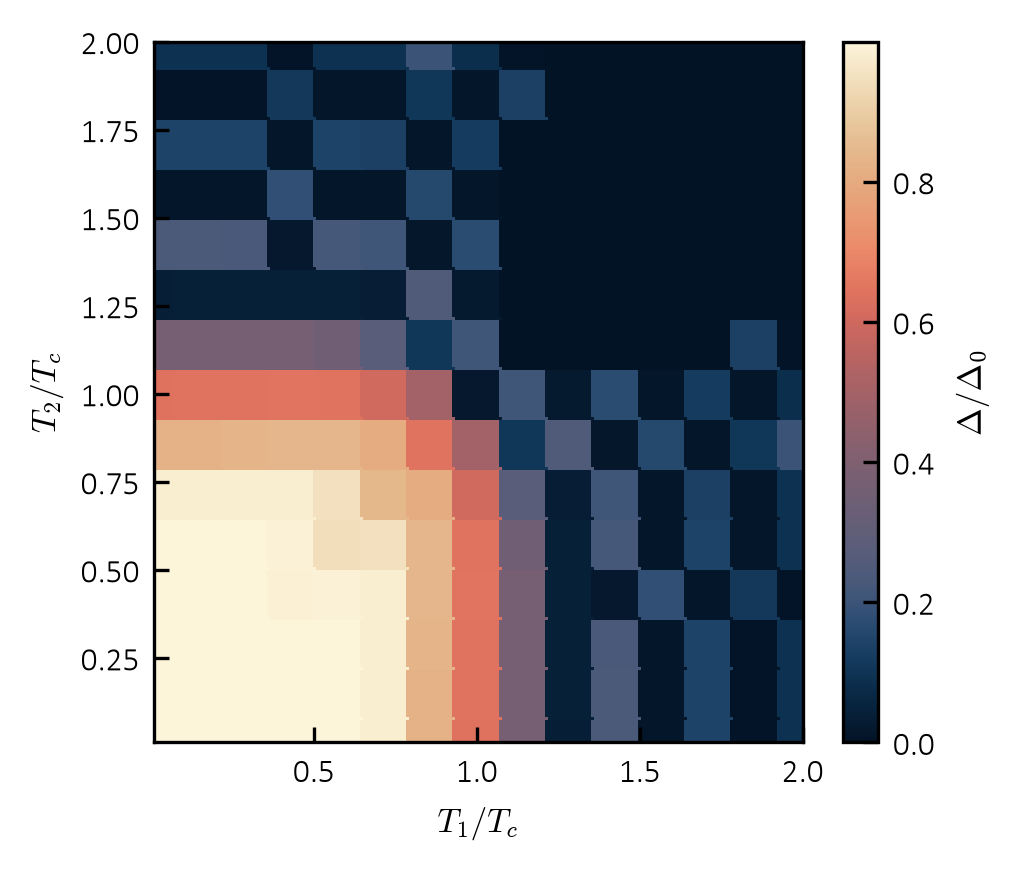

(<Figure size 347.412x295.3 with 2 Axes>,
 <Axes: xlabel='$T_1/T_c$', ylabel='$T_2/T_c$'>)

In [168]:
plot_phase_diag(da, d0, tn)
# plot_phase_diag(np.ma.masked_where(~ok, da), d0, tn)

In [169]:
print(tn.shape)

(15,)


In [170]:
print(da.shape)

(15, 15)


In [171]:
bp = {**bc["pars"], "eta": float(eta), "disp": "constant", "w0": 3.0, "ew": 1.0,}

Phonon kernel table:   0%|          | 0/64 [00:00<?, ?it/s]

max momentum error: 8.881784197001252e-16


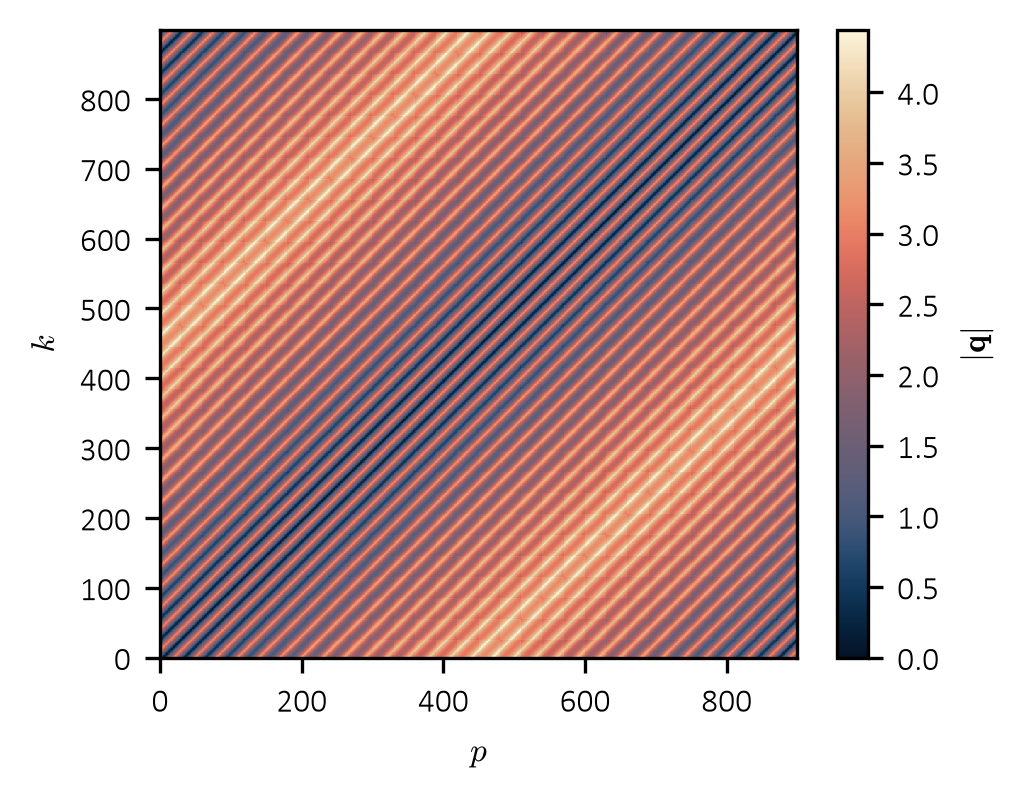

In [222]:
bp = pb.pack((bs[0],))

k = np.asarray(bp.k)
per = float(bp.per)

q = (
    k[:, None, :]
    - k[None, :, :]
    + 0.5 * per
) % per - 0.5 * per

er = (
    k[None, :, :]
    + q
    - k[:, None, :]
    + 0.5 * per
) % per - 0.5 * per

print("max momentum error:", np.max(np.abs(er)))

qm = np.linalg.norm(q, axis=-1)
ii = np.arange(k.shape[0])

h = 0.78
fig, ax = plt.subplots(
    figsize=(3.47412, h * 3.47412),
)

im = ax.pcolormesh(
    ii,
    ii,
    qm,
    shading="nearest",
    cmap=cmaps.lipari,
)
im.set_edgecolor("face")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r"$|\mathbf{q}|$", rotation=90, labelpad=5)

ax.set_xlim(ii[0], ii[-1])
ax.set_ylim(ii[0], ii[-1])
ax.set_xlabel(r"$p$")
ax.set_ylabel(r"$k$")

plt.tight_layout()
plt.show()

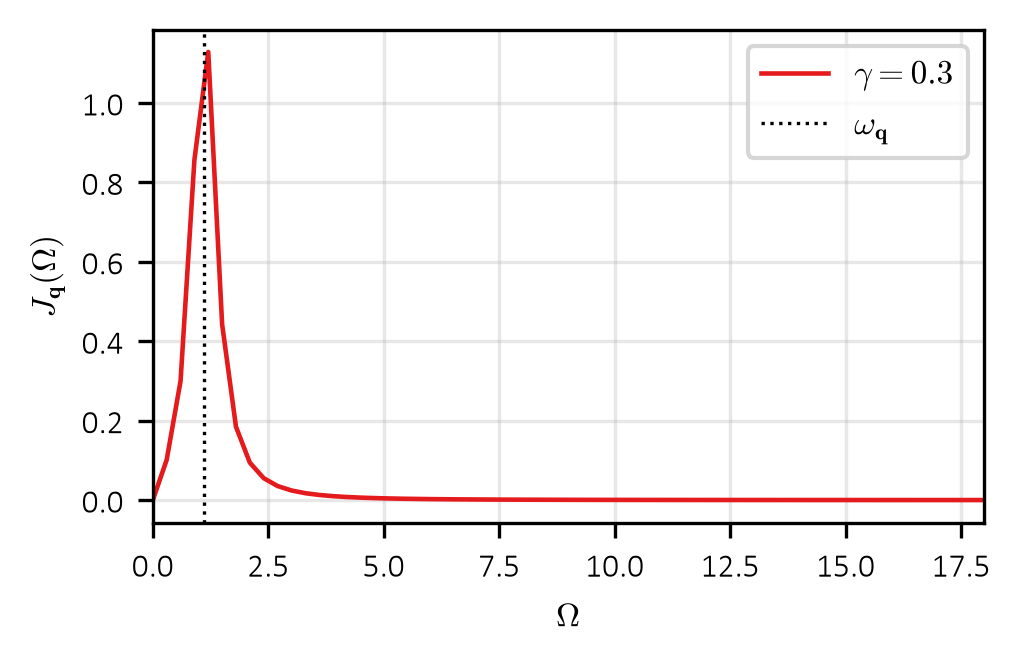

In [223]:
ib = 0
ik = 0
ip = k.shape[0] // 2

b = bs[ib]
q0 = q[ik, ip]
qm0 = np.linalg.norm(q0)
om0 = float(pb.omega_q(qm0, b))

eg = np.asarray(bp.eg)

if b.ew > 0.0:
    sp = np.asarray(
        pb._spec_e(
            jnp.asarray(eg),
            jnp.asarray(om0),
            jnp.asarray(b.ew),
        )
    )
    lb = rf"$\gamma={b.ew:g}$"
else:
    sp = np.asarray(
        pb._disc_e(
            jnp.asarray(eg),
            jnp.asarray(om0),
            bp.eh,
        )
    )
    lb = rf"$h_E={float(bp.eh):g}$"

h = 0.65
fig, ax = plt.subplots(
    figsize=(3.47412, h * 3.47412),
)

ax.plot(
    eg,
    sp,
    color=SET1_LIST[0],
    linewidth=1.1,
    label=lb,
)

ax.axvline(
    om0,
    color="black",
    linestyle=":",
    linewidth=0.8,
    label=r"$\omega_{\mathbf{q}}$",
)

ax.set_xlim(eg[0], eg[-1])
ax.set_xlabel(r"$\Omega$")
ax.set_ylabel(r"$J_{\mathbf{q}}(\Omega)$")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

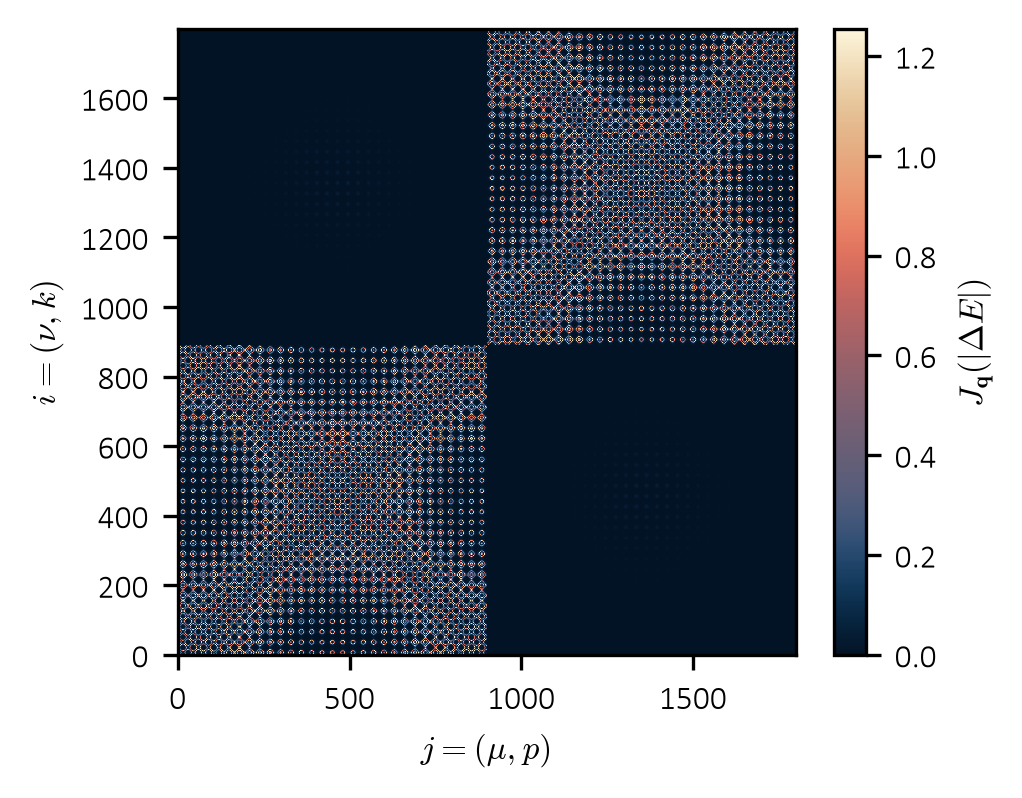

In [224]:
bp = pb.pack((bs[0],))
x = np.asarray(pb._data(st, bp))

de = x[:, 0, None] - x[None, :, 0]
ww = np.abs(de)

qx = (
    x[:, 3, None]
    - x[None, :, 3]
    + 0.5 * float(bp.per)
) % float(bp.per) - 0.5 * float(bp.per)

qy = (
    x[:, 4, None]
    - x[None, :, 4]
    + 0.5 * float(bp.per)
) % float(bp.per) - 0.5 * float(bp.per)

qm = np.hypot(qx, qy)

b = bs[0]
if b.disp == "constant":
    om = np.full_like(qm, b.w0)
elif b.disp == "acoustic":
    om = b.cs * qm
else:
    wg = 2.0 * np.pi / b.length
    om = np.hypot(wg, b.cs * qm)

sp, _ = pb._line(
    jnp.asarray(ww),
    jnp.asarray(om),
    jnp.asarray(b.ew),
    bp,
)
sp = np.asarray(sp)

ii = np.arange(x.shape[0])

h = 0.78
fig, ax = plt.subplots(
    figsize=(3.47412, h * 3.47412),
)

im = ax.pcolormesh(
    ii,
    ii,
    sp + np.finfo(float).tiny,
    shading="nearest",
    cmap=cmaps.lipari,
)
im.set_edgecolor("face")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(
    r"$J_{\mathbf{q}}(|\Delta E|)$",
    rotation=90,
    labelpad=5,
)

ax.set_xlim(ii[0], ii[-1])
ax.set_ylim(ii[0], ii[-1])
ax.set_xlabel(r"$j=(\mu,p)$")
ax.set_ylabel(r"$i=(\nu,k)$")

plt.tight_layout()
plt.show()

In [225]:
eh=0.5
e = np.asarray(st.e).reshape(-1)
ix = np.floor(e / eh).astype(int)

lo = ix.min()
hi = ix.max()

eg = (np.arange(lo, hi + 1) + 0.5) * eh
bw = np.bincount(
    ix - lo,
    weights=np.tile(np.asarray(bd.w), 2),
    minlength=hi - lo + 1,
)

In [226]:
print((hi+lo).mean())

-1.0


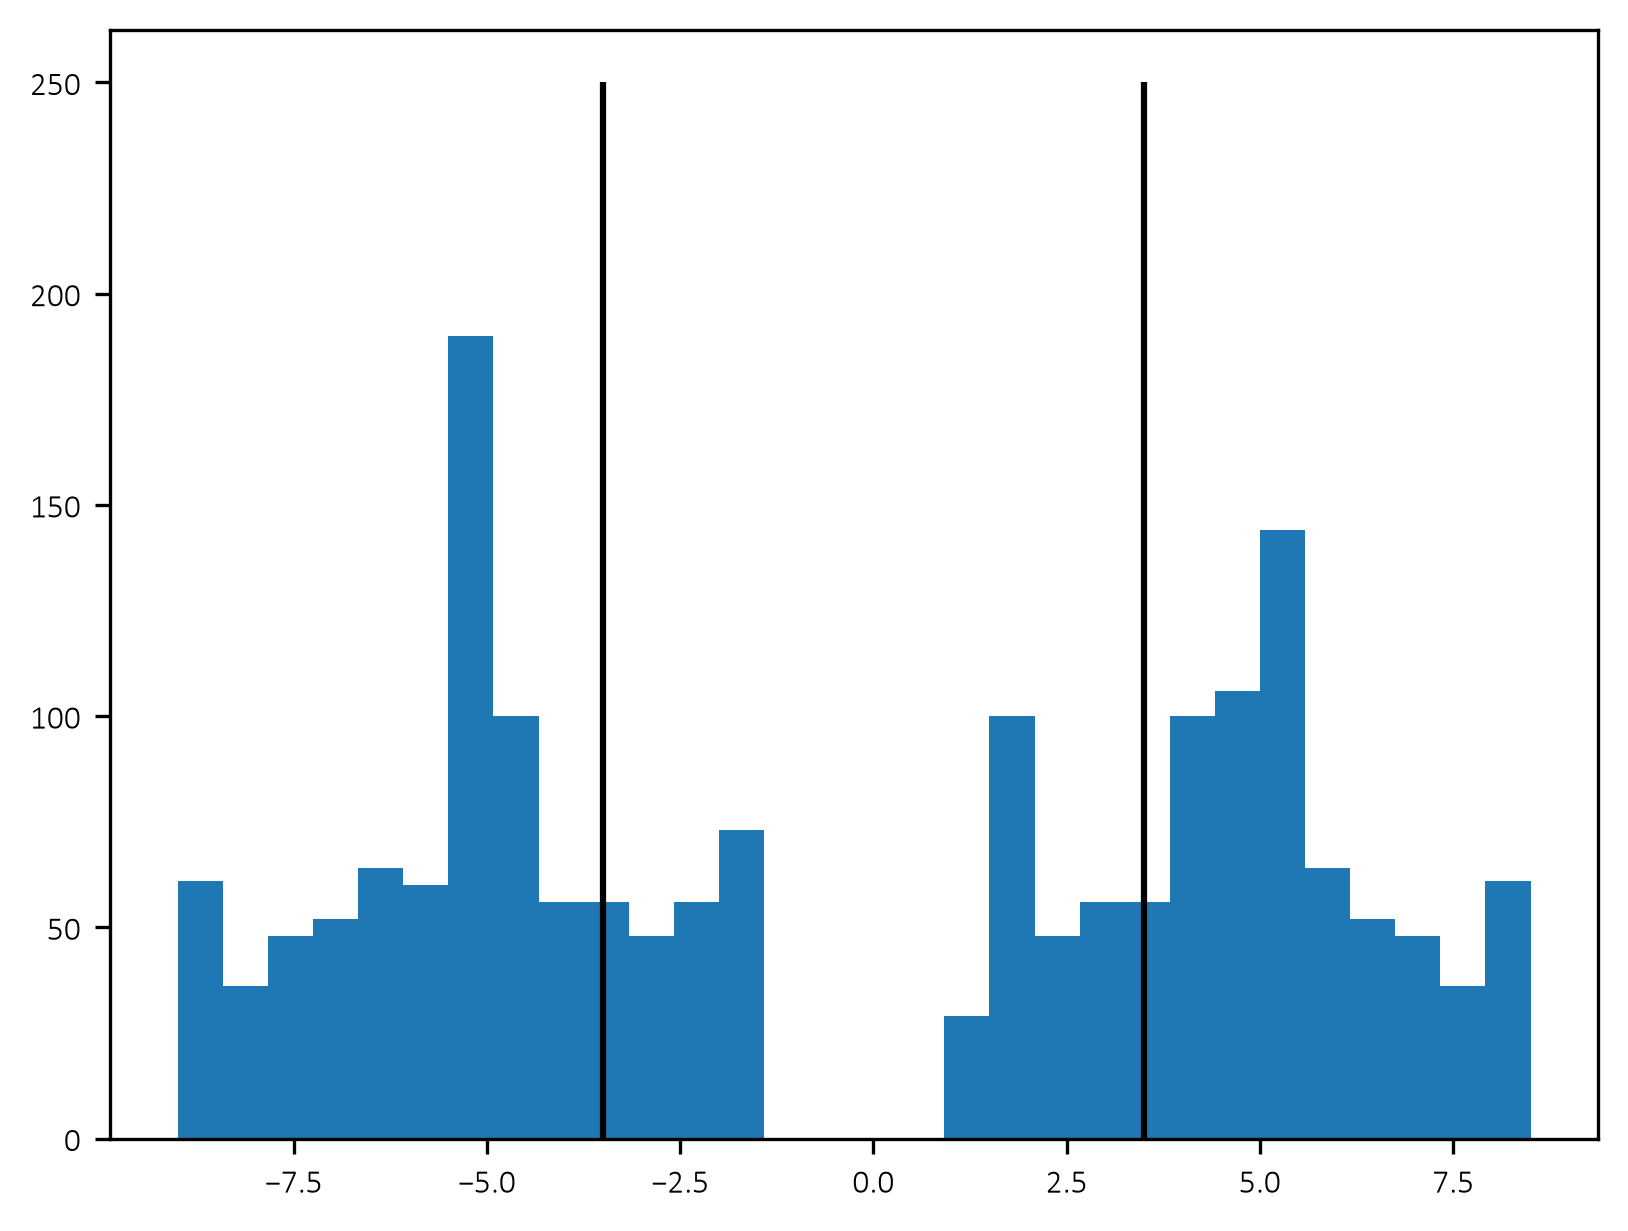

In [227]:
plt.hist((ix)*eh, 30)
plt.vlines(3.5, 0, 250 , color="k")
plt.vlines(-3.5, 0, 250, color="k")


In [228]:
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components

st = ej.mf_state(bd, p, d=so.d, m=so.m)
rr = np.asarray(ej.dense_rates(st, bs))

sc = np.max(rr)
ww = np.tile(np.asarray(bd.w), 2)
la = np.repeat(np.arange(2), bd.size)

for ep in (0.0, 1.0e-14, 1.0e-10, 1.0e-6):
    ma = (rr > ep * sc) | (rr.T > ep * sc)
    np.fill_diagonal(ma, False)

    nc, lb = connected_components(
        csr_matrix(ma),
        directed=False,
    )

    sz = np.bincount(lb)
    print(
        f"cut={ep:.0e}, components={nc}, "
        f"sizes={np.sort(sz)[::-1][:10]}"
    )

cut=0e+00, components=1800, sizes=[1 1 1 1 1 1 1 1 1 1]
cut=1e-14, components=1800, sizes=[1 1 1 1 1 1 1 1 1 1]
cut=1e-10, components=1800, sizes=[1 1 1 1 1 1 1 1 1 1]
cut=1e-06, components=1800, sizes=[1 1 1 1 1 1 1 1 1 1]


In [229]:
y = np.asarray(so.n).reshape(-1)

for c in range(lb.max() + 1):
    ii = np.flatnonzero(lb == c)

    wc = np.sum(ww[ii])
    nc = np.sum(ww[ii] * y[ii])
    fc = nc / wc

    na = np.count_nonzero(la[ii] == 0)
    nb = np.count_nonzero(la[ii] == 1)

    print(
        f"component={c}, states={ii.size}, "
        f"alpha={na}, beta={nb}, "
        f"weight={wc:.6f}, occupation={fc:.6f}"
    )

component=0, states=1, alpha=1, beta=0, weight=0.001111, occupation=0.003593
component=1, states=1, alpha=1, beta=0, weight=0.001111, occupation=0.003694
component=2, states=1, alpha=1, beta=0, weight=0.001111, occupation=0.004005
component=3, states=1, alpha=1, beta=0, weight=0.001111, occupation=0.004539
component=4, states=1, alpha=1, beta=0, weight=0.001111, occupation=0.005333
component=5, states=1, alpha=1, beta=0, weight=0.001111, occupation=0.006453
component=6, states=1, alpha=1, beta=0, weight=0.001111, occupation=0.007981
component=7, states=1, alpha=1, beta=0, weight=0.001111, occupation=0.010000
component=8, states=1, alpha=1, beta=0, weight=0.001111, occupation=0.012572
component=9, states=1, alpha=1, beta=0, weight=0.001111, occupation=0.015703
component=10, states=1, alpha=1, beta=0, weight=0.001111, occupation=0.019329
component=11, states=1, alpha=1, beta=0, weight=0.001111, occupation=0.023261
component=12, states=1, alpha=1, beta=0, weight=0.001111, occupation=0.027